## Proyecto Final Fase 2 - Forecasting de Dengue en Cali

### Flujo tipo Workshop S6 adaptado literalmente a la rubrica

**Objetivo:** comparar sistematicamente 8 modelos obligatorios para pronosticar casos semanales de dengue en Cali.

| Parte | Contenido | Modelos |
|---|---|---|
| 1 | Configuracion, librerias y helpers | - |
| 2 | Carga de datos en formato Nixtla | - |
| 3 | Split temporal e imputacion sin fuga | - |
| 4 | EDA: ACF/PACF, estacionalidad y brotes | - |
| 5 | Estacionariedad y transformaciones | - |
| 6 | Baselines de referencia | Naive, SeasonalNaive, WindowAverage, RWD |
| 7 | Familia ARIMA/SARIMA | AutoARIMA, SARIMA manual |
| 8 | Suavizacion exponencial | AutoETS, Theta |
| 9 | Feature engineering MLForecast | - |
| 10 | Modelos ML | Ridge, Lasso, Random Forest, LightGBM |
| 11 | Benchmark CV/test | 8 modelos + baselines |
| 12 | Residuos y seleccion final | - |

La estructura replica el espiritu del Workshop S6, pero las familias de modelos quedan separadas segun el PDF del entregable.


---
## PARTE 1: CONFIGURACION

Se usa frecuencia semanal `W-MON`, corte temporal `2020-01-01` y una hipotesis estacional cuatrienal de 208 semanas. El ciclo anual de 52 semanas se conserva como referencia epidemiologica interpretable.


In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tools import add_constant

from statsforecast import StatsForecast
from statsforecast.models import (
    ARIMA,
    AutoARIMA,
    AutoETS,
    DynamicOptimizedTheta,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    WindowAverage,
)

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, RollingMin, RollingMax
from mlforecast.target_transforms import Differences
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import fourier
from utilsforecast.losses import mae, mape, rmse

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)

RUTA_DATOS = Path('proyecto_2/dengue_anio_semana_nixtla.csv')
if not RUTA_DATOS.exists():
    RUTA_DATOS = Path('../proyecto_2/dengue_anio_semana_nixtla.csv')
if not RUTA_DATOS.exists():
    RUTA_DATOS = Path('proyecto_1/dengue_anio_semana_nixtla.csv')

UNIQUE_ID = 'dengue_cali'
FRECUENCIA = 'W-MON'
FECHA_CORTE = '2020-01-01'
ESTACIONALIDAD_ANUAL = 52
ESTACIONALIDAD = ESTACIONALIDAD_ANUAL * 4
SEED = 42

MODELOS_BASELINE = ['Naive', 'SeasonalNaive', 'WindowAverage', 'RWD']
MODELOS_ARIMA = [f'AutoARIMA_{ESTACIONALIDAD}', 'SARIMA_manual']
MODELOS_SUAVIZADO = [f'AutoETS_{ESTACIONALIDAD}', f'Theta_{ESTACIONALIDAD}']
MODELOS_ML_LINEALES = ['ridge', 'lasso']
MODELOS_ML_ENSEMBLE = ['random_forest', 'lightgbm']
MODELOS_ML = MODELOS_ML_LINEALES + MODELOS_ML_ENSEMBLE
MODELOS_FASE2 = MODELOS_ARIMA + MODELOS_SUAVIZADO + MODELOS_ML

print('Configuracion cargada')
print(f'Datos Nixtla: {RUTA_DATOS}')
print(f'Estacionalidad anual: {ESTACIONALIDAD_ANUAL} | Hipotesis principal: {ESTACIONALIDAD}')


/home/alejo/.virtualenvs/datascience-venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuracion cargada
Datos Nixtla: ../proyecto_2/dengue_anio_semana_nixtla.csv
Estacionalidad anual: 52 | Hipotesis principal: 208


In [ ]:
def estilo_ranking_metricas(tabla, columnas=None):
    """Resalta tablas largas de metricas: verde = menor error."""
    if columnas is None:
        columnas = [c for c in ['mae', 'mape', 'rmse', 'rmse_cv', 'rmse_test', 'ratio_rmse_test_cv'] if c in tabla.columns]
    formato = {c: '{:.2f}' for c in tabla.select_dtypes(include='number').columns}
    return tabla.style.background_gradient(cmap='RdYlGn_r', subset=columnas).format(formato)


def calcular_metricas_pronostico(datos, modelos, conjunto='test'):
    """Calcula MAE, RMSE y MAPE en formato largo."""
    evaluacion = evaluate(df=datos, metrics=[mae, rmse, mape], models=modelos, target_col='y')
    tabla = (
        evaluacion[['metric'] + [m for m in modelos if m in evaluacion.columns]]
        .melt(id_vars='metric', var_name='modelo', value_name='valor')
        .pivot_table(index='modelo', columns='metric', values='valor', aggfunc='mean')
        .reset_index()
    )
    tabla.columns.name = None
    tabla['mape'] *= 100
    tabla.insert(1, 'conjunto', conjunto)
    return tabla.sort_values('rmse').reset_index(drop=True)


METRICAS_TABLA = [mae, mape, rmse]
ORDEN_METRICAS = ['mae', 'mape', 'rmse']
NOMBRE_METRICA = {'mae': 'MAE', 'mape': 'MAPE (%)', 'rmse': 'RMSE'}


def preparar_tabla_metricas(evaluacion, modelos):
    """Convierte evaluate() a tabla: metricas x modelos."""
    tabla = evaluacion.drop(columns='unique_id', errors='ignore').groupby('metric', as_index=False)[modelos].mean()
    tabla.loc[tabla.metric == 'mape', modelos] *= 100
    tabla['metric'] = pd.Categorical(tabla['metric'], categories=ORDEN_METRICAS, ordered=True)
    tabla = tabla.sort_values('metric')
    tabla['metric'] = tabla['metric'].map(NOMBRE_METRICA)
    return tabla[['metric'] + modelos]


def estilo_tabla_metricas(tabla):
    """Estilo visual del Workshop S6: verde = menor error, rojo = mayor error."""
    modelo_cols = [c for c in tabla.columns if c != 'metric']
    return tabla.style.background_gradient(cmap='RdYlGn_r', axis=1, subset=modelo_cols).format({c: '{:.2f}' for c in modelo_cols})


def evaluar_cv_estilo(cv_df, modelos):
    evaluaciones = []
    for _, sub in cv_df.groupby('cutoff'):
        evaluaciones.append(evaluate(sub, metrics=METRICAS_TABLA, models=modelos, target_col='y'))
    return estilo_tabla_metricas(preparar_tabla_metricas(pd.concat(evaluaciones, ignore_index=True), modelos))


def evaluar_test_estilo(test_df, modelos):
    evaluacion = evaluate(test_df, metrics=METRICAS_TABLA, models=modelos, target_col='y')
    return estilo_tabla_metricas(preparar_tabla_metricas(evaluacion, modelos))


---
## PARTE 2: CARGA DE DATOS EN FORMATO NIXTLA

El archivo `dengue_anio_semana_nixtla.csv` ya contiene la serie agregada en formato Nixtla:

```text
unique_id | ds | y
```

En esta seccion solo se valida el esquema, se convierte `ds` a fecha y se completa el calendario semanal para detectar semanas faltantes.


In [3]:
def cargar_serie_nixtla(ruta_archivo, frecuencia=FRECUENCIA, unique_id=UNIQUE_ID):
    """Carga una serie en formato Nixtla: unique_id, ds, y."""
    serie = pd.read_csv(ruta_archivo)
    columnas_requeridas = {'unique_id', 'ds', 'y'}
    faltantes = columnas_requeridas.difference(serie.columns)
    if faltantes:
        raise ValueError(f'El archivo no tiene columnas Nixtla requeridas: {sorted(faltantes)}')

    serie = serie[['unique_id', 'ds', 'y']].copy()
    serie['ds'] = pd.to_datetime(serie['ds'], errors='coerce')
    serie['y'] = pd.to_numeric(serie['y'], errors='coerce')
    serie = serie.dropna(subset=['unique_id', 'ds']).sort_values(['unique_id', 'ds']).reset_index(drop=True)

    ids = serie['unique_id'].unique()
    if len(ids) != 1:
        raise ValueError(f'Este notebook espera una sola serie; unique_id encontrados: {ids.tolist()}')
    if ids[0] != unique_id:
        print(f"Aviso: unique_id en archivo = {ids[0]!r}; UNIQUE_ID configurado = {unique_id!r}")

    return serie


def completar_calendario(serie, frecuencia=FRECUENCIA):
    """Completa el calendario semanal conservando el formato Nixtla."""
    unique_id = serie['unique_id'].iloc[0]
    calendario = pd.DataFrame({'ds': pd.date_range(serie.ds.min(), serie.ds.max(), freq=frecuencia)})
    calendario['unique_id'] = unique_id
    return calendario.merge(serie, on=['unique_id', 'ds'], how='left')[['unique_id', 'ds', 'y']]


def diagnosticar_continuidad(serie):
    esperado = pd.date_range(serie.ds.min(), serie.ds.max(), freq=FRECUENCIA)
    faltantes = esperado.difference(serie.ds)
    print(f'Observaciones: {len(serie)} | Esperadas: {len(esperado)} | Fechas faltantes: {len(faltantes)} | NaN y: {serie.y.isna().sum()}')
    if len(faltantes):
        print(faltantes.tolist())


df = cargar_serie_nixtla(RUTA_DATOS)
print('Columnas:', df.columns.tolist())
print('Serie Nixtla cargada:')
diagnosticar_continuidad(df)

df = completar_calendario(df)
print('Serie Nixtla con calendario semanal completo:')
diagnosticar_continuidad(df)
display(df.head())
display(df.tail())


Columnas: ['unique_id', 'ds', 'y']
Serie Nixtla cargada:
Observaciones: 741 | Esperadas: 744 | Fechas faltantes: 3 | NaN y: 0
[Timestamp('2024-02-26 00:00:00'), Timestamp('2024-03-11 00:00:00'), Timestamp('2024-03-18 00:00:00')]
Serie Nixtla con calendario semanal completo:
Observaciones: 744 | Esperadas: 744 | Fechas faltantes: 0 | NaN y: 3


,unique_id,ds,y
0,dengue_cali,2009-12-28,12.0
1,dengue_cali,2010-01-04,142.0
2,dengue_cali,2010-01-11,210.0
3,dengue_cali,2010-01-18,253.0
4,dengue_cali,2010-01-25,345.0


,unique_id,ds,y
739,dengue_cali,2024-02-26,NaN
740,dengue_cali,2024-03-04,5.0
741,dengue_cali,2024-03-11,NaN
742,dengue_cali,2024-03-18,NaN
743,dengue_cali,2024-03-25,1.0


---
## PARTE 3: SPLIT TEMPORAL E IMPUTACION SIN FUGA

El split temporal usa el corte `2020-01-01`. La imputacion se calcula con medias por semana epidemiologica usando solo `train`, y luego se aplica a `train` y `test` para evitar fuga de informacion.


In [4]:
def separar_train_test(serie, fecha_corte=FECHA_CORTE):
    fecha_corte = pd.to_datetime(fecha_corte)
    return serie[serie.ds < fecha_corte].copy(), serie[serie.ds >= fecha_corte].copy()


def calcular_medias_estacionales(train):
    aux = train.copy()
    aux['semana_anio'] = aux.ds.dt.isocalendar().week.astype(int)
    return aux.groupby('semana_anio')['y'].mean().to_dict(), aux['y'].mean()


def imputar_por_media_estacional(datos, medias_estacionales, media_global):
    datos = datos.copy()
    semana = datos.ds.dt.isocalendar().week.astype(int)
    datos['y'] = datos['y'].where(datos['y'].notna(), semana.map(medias_estacionales).fillna(media_global))
    return datos


def graficar_split(train, test):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train.ds, y=train.y, mode='lines', name='Train', line=dict(color='#1f77b4')))
    fig.add_trace(go.Scatter(x=test.ds, y=test.y, mode='lines', name='Test', line=dict(color='#e74c3c')))
    fig.add_vline(x=pd.to_datetime(FECHA_CORTE), line_dash='dash', line_color='gray')
    fig.update_layout(title='Split temporal train/test', xaxis_title='Fecha', yaxis_title='Casos', template='plotly_white', height=420)
    fig.show()


train, test = separar_train_test(df)
medias_estacionales, media_global_train = calcular_medias_estacionales(train)
train = imputar_por_media_estacional(train, medias_estacionales, media_global_train)
test = imputar_por_media_estacional(test, medias_estacionales, media_global_train)
df = pd.concat([train, test], ignore_index=True).sort_values('ds').reset_index(drop=True)

print(f'TRAIN: {len(train)} observaciones ({train.ds.min().date()} -> {train.ds.max().date()})')
print(f'TEST:  {len(test)} observaciones ({test.ds.min().date()} -> {test.ds.max().date()})')
print(f'NaN total despues de imputar: {df.y.isna().sum()}')
graficar_split(train, test)


TRAIN: 523 observaciones (2009-12-28 -> 2019-12-30)
TEST:  221 observaciones (2020-01-06 -> 2024-03-25)
NaN total despues de imputar: 0


---
## PARTE 4: EDA - ACF, PACF Y ESTACIONALIDAD

Se revisan persistencia, dependencia parcial y soporte para referencias anuales/cuatrienales. La evidencia de 208 semanas se interpreta como hipotesis heredada, no como hecho epidemiologico definitivo.


In [5]:
def graficar_acf_pacf(serie, n_lags=ESTACIONALIDAD):
    valores = np.asarray(serie).astype(float)
    valores = valores[~np.isnan(valores)]
    n_lags = min(n_lags, len(valores) // 2 - 1)
    acf_vals = acf(valores, nlags=n_lags, fft=True)
    pacf_vals = pacf(valores, nlags=n_lags, method='ols')
    conf = 1.96 / np.sqrt(len(valores))

    fig = make_subplots(rows=1, cols=2, subplot_titles=('ACF', 'PACF'))
    for col, vals, color in [(1, acf_vals, '#1f77b4'), (2, pacf_vals, '#2ca02c')]:
        for lag, val in enumerate(vals):
            fig.add_trace(go.Bar(x=[lag], y=[val], marker_color=color if abs(val) > conf else 'lightgray', showlegend=False), row=1, col=col)
        fig.add_hline(y=conf, line_dash='dash', line_color='crimson', row=1, col=col)
        fig.add_hline(y=-conf, line_dash='dash', line_color='crimson', row=1, col=col)
    fig.update_layout(title='ACF y PACF - Casos semanales de dengue', template='plotly_white', height=430)
    fig.show()

    sig_acf = [lag for lag, val in enumerate(acf_vals[1:], start=1) if abs(val) > conf]
    sig_pacf = [lag for lag, val in enumerate(pacf_vals[1:], start=1) if abs(val) > conf]
    return acf_vals, pacf_vals, sig_acf, sig_pacf, conf


acf_vals, pacf_vals, sig_acf, sig_pacf, conf_int = graficar_acf_pacf(df.y)
print(f'IC aproximado 95%: +/- {conf_int:.3f}')
print(f'Primeros lags significativos ACF:  {sig_acf[:15]}')
print(f'Primeros lags significativos PACF: {sig_pacf[:15]}')

acf_estacional = pd.DataFrame([
    {'lag': lag, 'acf': acf_vals[lag], 'interpretacion': 'significativo' if abs(acf_vals[lag]) > conf_int else 'no significativo'}
    for lag in [52, 104, 156, 208]
    if lag < len(acf_vals)
])
display(acf_estacional)

lags_sugeridos_ml = sorted(set([lag for lag in sig_pacf[:8] if lag <= 24] + [ESTACIONALIDAD_ANUAL]))
print(f'Lags sugeridos por PACF + referencia anual: {lags_sugeridos_ml}')


IC aproximado 95%: +/- 0.072
Primeros lags significativos ACF:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Primeros lags significativos PACF: [1, 2, 3, 4, 5, 8, 11, 13, 18, 20, 23, 24, 25, 26, 28]


,lag,acf,interpretacion
0,52,-0.092103,significativo
1,104,-0.169386,significativo
2,156,0.040873,no significativo
3,208,0.039015,no significativo


Lags sugeridos por PACF + referencia anual: [1, 2, 3, 4, 5, 8, 11, 13, 52]


In [6]:
q1, q3 = df.y.quantile([0.25, 0.75])
umbral_brote = q3 + 1.5 * (q3 - q1)
semanas_brote = df[df.y > umbral_brote]

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.ds, y=df.y, mode='lines', name='Casos semanales', line=dict(color='#1f77b4')))
fig.add_trace(go.Scatter(x=semanas_brote.ds, y=semanas_brote.y, mode='markers', name='Semanas extremas', marker=dict(color='#e74c3c', size=5)))
fig.add_hline(y=umbral_brote, line_dash='dash', line_color='#e74c3c', annotation_text=f'Umbral IQR = {umbral_brote:.0f}')
fig.update_layout(title='Serie temporal y semanas de brote', xaxis_title='Semana', yaxis_title='Casos', template='plotly_white', height=430)
fig.show()
print(f'Semanas extremas detectadas: {len(semanas_brote)}')


Semanas extremas detectadas: 57


---
## PARTE 5: ESTACIONARIEDAD Y TRANSFORMACIONES

Se prueban la serie original y diferencias anuales/cuatrienales. En los modelos ML se conserva la escala original (`TGTTR=None`) si ADF/KPSS respaldan estacionariedad.


In [7]:
def adf_report(series, nombre):
    stat, pval, *_ = adfuller(pd.Series(series).dropna(), autolag='AIC')
    print(f'ADF — {nombre}: stat={stat:.4f} | p={pval:.4f} -> {"estacionaria" if pval <= 0.05 else "no estacionaria"}')
    return pval


def test_estacionaridad(serie, nombre):
    arr = np.asarray(serie).astype(float)
    arr = arr[~np.isnan(arr)]
    adf_stat, adf_p, *_ = adfuller(arr, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(arr, regression='c', nlags='auto')
    conclusion = 'estacionaria' if adf_p < 0.05 and kpss_p >= 0.05 else 'incierta/no estacionaria'
    print(f'{nombre}')
    print(f'ADF:  stat={adf_stat:.4f} | p={adf_p:.4f}')
    print(f'KPSS: stat={kpss_stat:.4f} | p={kpss_p:.4f}')
    print(f'Conclusion conjunta: {conclusion}')
    return {'adf_p': adf_p, 'kpss_p': kpss_p, 'estacionaria': adf_p < 0.05 and kpss_p >= 0.05}


adf_report(df.y, 'serie original imputada')
adf_report(df.y.diff(ESTACIONALIDAD_ANUAL), f'diff({ESTACIONALIDAD_ANUAL}) anual')
adf_report(df.y.diff(ESTACIONALIDAD), f'diff({ESTACIONALIDAD}) cuatrienal')
r_estacionariedad = test_estacionaridad(df.y, 'Casos de dengue en Cali - serie imputada')
TGTTR = None
print('Decision MLForecast: TGTTR=None para mantener escala original e interpretabilidad sanitaria.')


ADF — serie original imputada: stat=-5.0818 | p=0.0000 -> estacionaria
ADF — diff(52) anual: stat=-4.5456 | p=0.0002 -> estacionaria
ADF — diff(208) cuatrienal: stat=-3.8879 | p=0.0021 -> estacionaria
Casos de dengue en Cali - serie imputada
ADF:  stat=-5.0818 | p=0.0000
KPSS: stat=0.1358 | p=0.1000
Conclusion conjunta: estacionaria
Decision MLForecast: TGTTR=None para mantener escala original e interpretabilidad sanitaria.


In [8]:
def plot_diferencias(datos_base, differences, freq=FRECUENCIA):
    prep_list = [datos_base.assign(unique_id='original')]
    for d in differences:
        fcst = MLForecast(models=[], freq=freq, target_transforms=[Differences([d])])
        aux = fcst.preprocess(datos_base.copy(), static_features=[])
        aux['unique_id'] = f'diff({d})'
        prep_list.append(aux)
    prep = pd.concat(prep_list, ignore_index=True)

    fig = go.Figure()
    for uid in prep.unique_id.unique():
        sub = prep[prep.unique_id == uid]
        fig.add_trace(go.Scatter(x=sub.ds, y=sub.y, mode='lines', name=uid))
    fig.update_layout(title='Efecto de diferenciaciones sobre la serie', xaxis_title='Fecha', yaxis_title='Valor transformado', template='plotly_white', height=430)
    fig.show()


plot_diferencias(df[['unique_id', 'ds', 'y']], differences=[1, 4, 28, 52])

ljung = []
for lag in [1, 6, 12, 18, 24, 52]:
    out = acorr_ljungbox(df.y.values, lags=[lag], return_df=True)
    ljung.append({'lag': lag, 'q_stat': out['lb_stat'].iloc[0], 'p_valor': out['lb_pvalue'].iloc[0], 'hay_autocorrelacion': out['lb_pvalue'].iloc[0] < 0.05})
display(pd.DataFrame(ljung))


,lag,q_stat,p_valor,hay_autocorrelacion
0,1,680.343848,5.625361e-150,True
1,6,3264.086657,0.000000e+00,True
2,12,4851.421001,0.000000e+00,True
3,18,5562.677688,0.000000e+00,True
4,24,5778.253770,0.000000e+00,True
5,52,5881.216601,0.000000e+00,True


---
## PARTE 6: BASELINES DE REFERENCIA

Los baselines se usan como referencia cuantitativa para medir mejora porcentual. No cuentan dentro de los 8 modelos obligatorios de fase 2.


In [9]:
def crear_statsforecast_baseline(frecuencia=FRECUENCIA, estacionalidad=ESTACIONALIDAD):
    return StatsForecast(
        models=[Naive(), SeasonalNaive(season_length=estacionalidad), WindowAverage(window_size=3), RandomWalkWithDrift()],
        freq=frecuencia,
    )


def unir_predicciones_con_test(test, preds):
    return test.merge(preds, on=['unique_id', 'ds'])


def graficar_pronosticos(serie, test, preds_test, modelos, titulo):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=serie.ds, y=serie.y, mode='lines', name='Historico', line=dict(color='lightgray')))
    fig.add_trace(go.Scatter(x=test.ds, y=test.y, mode='lines', name='Real test', line=dict(color='black', width=2)))
    for modelo in modelos:
        fig.add_trace(go.Scatter(x=preds_test.ds, y=preds_test[modelo], mode='lines', name=modelo))
    fig.add_vline(x=pd.to_datetime(FECHA_CORTE), line_dash='dash', line_color='gray')
    fig.update_layout(title=titulo, xaxis_title='Fecha', yaxis_title='Casos', template='plotly_white', height=460)
    fig.show()


sf_baseline = crear_statsforecast_baseline()
sf_baseline.fit(train)
preds_baseline = sf_baseline.predict(h=len(test))
modelos_baseline = [c for c in preds_baseline.columns if c not in ['unique_id', 'ds']]
test_baseline = unir_predicciones_con_test(test, preds_baseline)
metricas_baseline = calcular_metricas_pronostico(test_baseline, modelos_baseline)

graficar_pronosticos(df, test, test_baseline, modelos_baseline, 'Baselines de referencia vs test')
display(estilo_ranking_metricas(metricas_baseline))


,modelo,conjunto,mae,mape,rmse
0,WindowAverage,test,99.93,299.54,115.62
1,SeasonalNaive,test,81.83,369.36,121.82
2,Naive,test,111.99,351.03,123.14
3,RWD,test,130.19,464.71,140.11


---
## PARTE 7: FAMILIA ARIMA/SARIMA (2 MODELOS)

Requisito del entregable: seleccionar 2 modelos de la familia ARIMA. Se usan:

- `AutoARIMA_208`: busqueda automatica con estacionalidad cuatrienal heredada.
- `SARIMA_manual`: parametrizacion `(2,0,2)(1,0,1)[208]`, motivada por persistencia de corto plazo y una hipotesis estacional.


In [10]:
def entrenar_y_predecir_statsforecast(train, test, modelos):
    inicio = time.perf_counter()
    sf = StatsForecast(models=modelos, freq=FRECUENCIA, n_jobs=-1)
    sf.fit(train)
    preds = sf.predict(h=len(test))
    return sf, preds, time.perf_counter() - inicio


modelos_arima = [
    AutoARIMA(season_length=ESTACIONALIDAD, alias=f'AutoARIMA_{ESTACIONALIDAD}'),
    ARIMA(order=(2, 0, 2), seasonal_order=(1, 0, 1), season_length=ESTACIONALIDAD, alias='SARIMA_manual'),
]

sf_arima, preds_arima, tiempo_arima = entrenar_y_predecir_statsforecast(train, test, modelos_arima)
modelos_arima_col = [c for c in preds_arima.columns if c not in ['unique_id', 'ds']]
test_arima = unir_predicciones_con_test(test, preds_arima)
test_arima[modelos_arima_col] = test_arima[modelos_arima_col].clip(lower=0)

metricas_arima = calcular_metricas_pronostico(test_arima, modelos_arima_col)
metricas_arima['familia'] = 'arima_sarima'
metricas_arima['tiempo_segundos'] = tiempo_arima
display(estilo_ranking_metricas(metricas_arima))


,modelo,conjunto,mae,mape,rmse,familia,tiempo_segundos
0,SARIMA_manual,test,61.94,117.06,109.01,arima_sarima,17.80
1,AutoARIMA_208,test,118.39,377.18,127.95,arima_sarima,17.80


---
## PARTE 8: SUAVIZACION EXPONENCIAL (2 MODELOS)

Requisito del entregable: seleccionar 2 modelos de suavizacion exponencial. Se usan:

- `AutoETS_208`: seleccion automatica de forma de error/tendencia/estacionalidad.
- `Theta_208`: modelo Theta optimizado, competitivo como suavizador robusto.


In [11]:
modelos_suavizado = [
    AutoETS(season_length=ESTACIONALIDAD, model='ZZZ', alias=f'AutoETS_{ESTACIONALIDAD}'),
    DynamicOptimizedTheta(season_length=ESTACIONALIDAD, alias=f'Theta_{ESTACIONALIDAD}'),
]

sf_suavizado, preds_suavizado, tiempo_suavizado = entrenar_y_predecir_statsforecast(train, test, modelos_suavizado)
modelos_suavizado_col = [c for c in preds_suavizado.columns if c not in ['unique_id', 'ds']]
test_suavizado = unir_predicciones_con_test(test, preds_suavizado)
test_suavizado[modelos_suavizado_col] = test_suavizado[modelos_suavizado_col].clip(lower=0)

metricas_suavizado = calcular_metricas_pronostico(test_suavizado, modelos_suavizado_col)
metricas_suavizado['familia'] = 'suavizacion'
metricas_suavizado['tiempo_segundos'] = tiempo_suavizado
display(estilo_ranking_metricas(metricas_suavizado))


,modelo,conjunto,mae,mape,rmse,familia,tiempo_segundos
0,Theta_208,test,111.83,350.36,123.03,suavizacion,3.26
1,AutoETS_208,test,162.26,653.50,179.45,suavizacion,3.26


---
## PARTE 9: FEATURE ENGINEERING PARA MACHINE LEARNING

Antes de entrenar modelos ML, se construyen las variables requeridas por la rubrica: lags, ventanas deslizantes, calendario y transformaciones aplicables.


In [12]:
FREQ = FRECUENCIA
LAGS = sorted(set(lags_sugeridos_ml + [12, 24, ESTACIONALIDAD_ANUAL]))
VENTANAS_ROLLING = [4, 8, 12, 24]
LAG_TR = {
    1: [transformacion(window_size=ventana) for ventana in VENTANAS_ROLLING for transformacion in [RollingMean, RollingStd, RollingMin, RollingMax]]
}

# Fourier cuatrienal como hipotesis suave; ciclo anual queda como lag52 y semana_iso.
df_fourier, _ = fourier(df, freq=FREQ, season_length=ESTACIONALIDAD, k=2, h=1)
FOURIER_COLS = [c for c in df_fourier.columns if c not in df.columns]


def agregar_calendario(serie):
    datos = serie.copy().sort_values('ds').reset_index(drop=True)
    datos['semana_iso'] = datos.ds.dt.isocalendar().week.astype(int)
    t = np.arange(len(datos))
    datos['ciclo_sin_208'] = np.sin(2 * np.pi * t / ESTACIONALIDAD)
    datos['ciclo_cos_208'] = np.cos(2 * np.pi * t / ESTACIONALIDAD)
    return datos


df_ml = agregar_calendario(df_fourier)
CALENDAR_COLS = ['semana_iso', 'ciclo_sin_208', 'ciclo_cos_208']
DATE_F = ['month', 'quarter', 'year']


def crear_mlforecast(modelos):
    return MLForecast(models=modelos, freq=FREQ, lags=LAGS, lag_transforms=LAG_TR, date_features=DATE_F, target_transforms=TGTTR)


fcst_explorer = crear_mlforecast(modelos=[])
features_df = fcst_explorer.preprocess(df_ml[['unique_id', 'ds', 'y'] + FOURIER_COLS + CALENDAR_COLS], static_features=[])
feature_cols = [c for c in features_df.columns if c not in ['unique_id', 'ds', 'y']]
print(f'LAGS: {LAGS}')
print(f'Dimensiones features: {features_df.shape}')
for c in feature_cols:
    print(f'  - {c}')
display(features_df.tail())

train_ml = df_ml[df_ml.ds < pd.to_datetime(FECHA_CORTE)].copy()
test_ml = df_ml[df_ml.ds >= pd.to_datetime(FECHA_CORTE)].copy()
X_test_ml = test_ml.drop(columns='y')


LAGS: [1, 2, 3, 4, 5, 8, 11, 12, 13, 24, 52]
Dimensiones features: (692, 40)
  - sin1_208
  - sin2_208
  - cos1_208
  - cos2_208
  - semana_iso
  - ciclo_sin_208
  - ciclo_cos_208
  - lag1
  - lag2
  - lag3
  - lag4
  - lag5
  - lag8
  - lag11
  - lag12
  - lag13
  - lag24
  - lag52
  - rolling_mean_lag1_window_size4
  - rolling_std_lag1_window_size4
  - rolling_min_lag1_window_size4
  - rolling_max_lag1_window_size4
  - rolling_mean_lag1_window_size8
  - rolling_std_lag1_window_size8
  - rolling_min_lag1_window_size8
  - rolling_max_lag1_window_size8
  - rolling_mean_lag1_window_size12
  - rolling_std_lag1_window_size12
  - rolling_min_lag1_window_size12
  - rolling_max_lag1_window_size12
  - rolling_mean_lag1_window_size24
  - rolling_std_lag1_window_size24
  - rolling_min_lag1_window_size24
  - rolling_max_lag1_window_size24
  - month
  - quarter
  - year


,unique_id,ds,y,sin1_208,sin2_208,cos1_208,cos2_208,semana_iso,ciclo_sin_208,ciclo_cos_208,...,rolling_std_lag1_window_size12,rolling_min_lag1_window_size12,rolling_max_lag1_window_size12,rolling_mean_lag1_window_size24,rolling_std_lag1_window_size24,rolling_min_lag1_window_size24,rolling_max_lag1_window_size24,month,quarter,year
739,dengue_cali,2024-02-26,121.8,-0.354604,0.663122,-0.935016,0.748511,9,-0.326203,-0.945300,...,220.606653,3.0,537.0,259.250000,175.089108,3.0,537.0,2,1,2024
740,dengue_cali,2024-03-04,5.0,-0.382682,0.707105,-0.923880,0.707109,10,-0.354605,-0.935016,...,207.720132,3.0,537.0,249.366667,175.906424,3.0,537.0,3,1,2024
741,dengue_cali,2024-03-11,103.2,-0.410412,0.748510,-0.911900,0.663123,11,-0.382683,-0.923880,...,190.429985,3.0,537.0,233.658333,180.324832,3.0,537.0,3,1,2024
742,dengue_cali,2024-03-18,89.8,-0.437766,0.787182,-0.899089,0.616721,12,-0.410413,-0.911900,...,155.947951,3.0,537.0,223.041667,180.186550,3.0,537.0,3,1,2024
743,dengue_cali,2024-03-25,1.0,-0.464723,0.822983,-0.885456,0.568065,13,-0.437768,-0.899088,...,67.167802,3.0,213.0,213.033333,180.657578,3.0,537.0,3,1,2024


In [13]:
corr = features_df[feature_cols + ['y']].corr(numeric_only=True)['y'].drop('y').sort_values(key=abs, ascending=False)
fig = go.Figure(go.Bar(x=corr.values, y=corr.index, orientation='h', marker_color=['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]))
fig.update_layout(title='Correlacion de features con el target', xaxis_title='Correlacion', yaxis_title='Feature', template='plotly_white', height=560)
fig.show()


---
## PARTE 10: MODELOS DE MACHINE LEARNING (4 MODELOS)

### 10A. Metodos lineales (2 modelos)

De la lista del entregable se seleccionan:

- `Ridge Regression`.
- `Lasso Regression`.

Ambos usan escalamiento porque son modelos lineales regularizados.


In [14]:
FAMILIA_ML = {
    'ridge': 'ml_lineal',
    'lasso': 'ml_lineal',
    'random_forest': 'ml_ensemble_boosting',
    'lightgbm': 'ml_ensemble_boosting',
}


def evaluar_candidato_ml(nombre, modelo, train_ml, h=26, n_windows=3, step_size=26):
    fcst = crear_mlforecast({nombre: modelo})
    cv = fcst.cross_validation(df=train_ml, h=h, n_windows=n_windows, step_size=step_size, refit=True, static_features=[])
    return calcular_metricas_pronostico(cv, [nombre], conjunto='cv').loc[0, 'rmse']


def seleccionar_mejor_candidato(nombre, opciones, train_ml):
    filas = []
    for etiqueta, modelo in opciones:
        filas.append({'modelo': nombre, 'parametros': etiqueta, 'rmse_cv': evaluar_candidato_ml(nombre, modelo, train_ml)})
    resultados = pd.DataFrame(filas)
    mejor = resultados.sort_values('rmse_cv').iloc[0]
    return dict(opciones)[mejor['parametros']], resultados


candidatos_lineales = {
    'ridge': [
        ('alpha=0.1', make_pipeline(StandardScaler(), Ridge(alpha=0.1))),
        ('alpha=1.0', make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
        ('alpha=10.0', make_pipeline(StandardScaler(), Ridge(alpha=10.0))),
    ],
    'lasso': [
        ('alpha=0.01', make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=10000, random_state=SEED))),
        ('alpha=0.05', make_pipeline(StandardScaler(), Lasso(alpha=0.05, max_iter=10000, random_state=SEED))),
        ('alpha=0.10', make_pipeline(StandardScaler(), Lasso(alpha=0.10, max_iter=10000, random_state=SEED))),
    ],
}

modelos_ml_lineales = {}
resultados_lineales = []
for nombre, opciones in candidatos_lineales.items():
    modelo, resultados = seleccionar_mejor_candidato(nombre, opciones, train_ml)
    modelos_ml_lineales[nombre] = modelo
    resultados_lineales.append(resultados)

resultados_lineales = pd.concat(resultados_lineales, ignore_index=True)
resultados_lineales['familia'] = 'ml_lineal'
display(estilo_ranking_metricas(resultados_lineales.sort_values(['modelo', 'rmse_cv']), columnas=['rmse_cv']))


,modelo,parametros,rmse_cv,familia
5,lasso,alpha=0.10,27.78,ml_lineal
4,lasso,alpha=0.05,29.69,ml_lineal
3,lasso,alpha=0.01,30.27,ml_lineal
2,ridge,alpha=10.0,29.28,ml_lineal
1,ridge,alpha=1.0,30.01,ml_lineal
0,ridge,alpha=0.1,30.22,ml_lineal


### 10B. Metodos de ensamble y boosting (2 modelos)

De la lista del entregable se seleccionan:

- `Random Forest` como ensemble basado en bagging.
- `LightGBM` como gradient boosting.


In [15]:
candidatos_ensemble = {
    'random_forest': [
        ('depth=5_leaf=3', RandomForestRegressor(n_estimators=150, max_depth=5, min_samples_leaf=3, random_state=SEED, n_jobs=-1)),
        ('depth=8_leaf=3', RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=3, random_state=SEED, n_jobs=-1)),
    ],
    'lightgbm': [
        ('n=250_lr=0.03_leaves=15', LGBMRegressor(n_estimators=250, learning_rate=0.03, num_leaves=15, min_child_samples=15, random_state=SEED, n_jobs=-1, verbose=-1)),
        ('n=500_lr=0.03_leaves=31', LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31, min_child_samples=15, random_state=SEED, n_jobs=-1, verbose=-1)),
    ],
}

modelos_ml_ensemble = {}
resultados_ensemble = []
for nombre, opciones in candidatos_ensemble.items():
    modelo, resultados = seleccionar_mejor_candidato(nombre, opciones, train_ml)
    modelos_ml_ensemble[nombre] = modelo
    resultados_ensemble.append(resultados)

resultados_ensemble = pd.concat(resultados_ensemble, ignore_index=True)
resultados_ensemble['familia'] = 'ml_ensemble_boosting'
display(estilo_ranking_metricas(resultados_ensemble.sort_values(['modelo', 'rmse_cv']), columnas=['rmse_cv']))


,modelo,parametros,rmse_cv,familia
2,lightgbm,n=250_lr=0.03_leaves=15,23.38,ml_ensemble_boosting
3,lightgbm,n=500_lr=0.03_leaves=31,23.43,ml_ensemble_boosting
1,random_forest,depth=8_leaf=3,23.52,ml_ensemble_boosting
0,random_forest,depth=5_leaf=3,23.84,ml_ensemble_boosting


In [16]:
def entrenar_y_predecir_ml(train_ml, test_ml, modelos_ml):
    inicio = time.perf_counter()
    fcst = crear_mlforecast(modelos_ml)
    fcst.fit(train_ml, static_features=[])
    preds = fcst.predict(h=len(test_ml), X_df=X_test_ml)
    return fcst, preds, time.perf_counter() - inicio


modelos_ml = {**modelos_ml_lineales, **modelos_ml_ensemble}
resultados_tuning_ml = pd.concat([resultados_lineales, resultados_ensemble], ignore_index=True)

fcst_ml, preds_ml, tiempo_ml = entrenar_y_predecir_ml(train_ml, test_ml, modelos_ml)
modelos_ml_col = [c for c in preds_ml.columns if c not in ['unique_id', 'ds']]
test_ml_pred = unir_predicciones_con_test(test, preds_ml)
test_ml_pred[modelos_ml_col] = test_ml_pred[modelos_ml_col].clip(lower=0)

metricas_ml = calcular_metricas_pronostico(test_ml_pred, modelos_ml_col)
metricas_ml['familia'] = metricas_ml['modelo'].map(FAMILIA_ML)
metricas_ml['tiempo_segundos'] = tiempo_ml
display(estilo_ranking_metricas(metricas_ml.sort_values(['familia', 'rmse'])))


,modelo,conjunto,mae,mape,rmse,familia,tiempo_segundos
0,lightgbm,test,90.36,369.69,101.56,ml_ensemble_boosting,7.62
1,random_forest,test,113.56,380.63,123.75,ml_ensemble_boosting,7.62
2,lasso,test,88.78,82.80,134.06,ml_lineal,7.62
3,ridge,test,91.10,84.36,135.98,ml_lineal,7.62


---
## PARTE 11: CROSS-VALIDATION Y BENCHMARK COMPLETO

Se consolida un benchmark tipo Workshop S6: tabla ancha de metricas por modelo, ranking largo por familia, tiempo y mejoras frente a baselines.


In [33]:
def ejecutar_validacion_cruzada(sf, serie, h=52, n_windows=3, step_size=52):
    return sf.cross_validation(df=serie, h=h, n_windows=n_windows, step_size=step_size)


def metricas_cv_por_modelo(cv, modelos):
    filas = []
    for cutoff, sub in cv.groupby('cutoff'):
        m = calcular_metricas_pronostico(sub, modelos, conjunto='cv')
        m['cutoff'] = cutoff
        filas.append(m)
    detalle = pd.concat(filas, ignore_index=True)
    resumen = detalle.groupby('modelo', as_index=False)[['mae', 'rmse', 'mape']].mean()
    return detalle, resumen.sort_values('rmse')


cv_baseline = ejecutar_validacion_cruzada(sf_baseline, train)
_, metricas_cv_baseline = metricas_cv_por_modelo(cv_baseline, modelos_baseline)

cv_arima = ejecutar_validacion_cruzada(sf_arima, train)
_, metricas_cv_arima = metricas_cv_por_modelo(cv_arima, modelos_arima_col)

cv_suavizado = ejecutar_validacion_cruzada(sf_suavizado, train)
_, metricas_cv_suavizado = metricas_cv_por_modelo(cv_suavizado, modelos_suavizado_col)

cv_ml = fcst_ml.cross_validation(df=train_ml, h=52, n_windows=3, step_size=52, refit=True, static_features=[])
_, metricas_cv_ml = metricas_cv_por_modelo(cv_ml, modelos_ml_col)

cv_completo = (
    cv_baseline
    .merge(cv_arima.drop(columns='y'), on=['unique_id', 'ds', 'cutoff'], how='left')
    .merge(cv_suavizado.drop(columns='y'), on=['unique_id', 'ds', 'cutoff'], how='left')
    .merge(cv_ml.drop(columns='y'), on=['unique_id', 'ds', 'cutoff'], how='left')
)
modelos_cv_completo = modelos_baseline + modelos_arima_col + modelos_suavizado_col + modelos_ml_col

resumen_folds = cv_completo.groupby('cutoff').agg(inicio_test=('ds', 'min'), fin_test=('ds', 'max'), semanas=('ds', 'count')).reset_index()
print(f'CV completo: {cv_completo.shape[0]} filas x {cv_completo.shape[1]} columnas')
display(resumen_folds)

print('Benchmark completo — Cross-Validation:')
display(evaluar_cv_estilo(cv_completo, modelos_cv_completo))


CV completo: 156 filas x 16 columnas


,cutoff,inicio_test,fin_test,semanas
0,2017-01-02,2017-01-09,2018-01-01,52
1,2018-01-01,2018-01-08,2018-12-31,52
2,2018-12-31,2019-01-07,2019-12-30,52


Benchmark completo — Cross-Validation:


In [ ]:
familia_modelo = {
    **{modelo: 'baseline' for modelo in modelos_baseline},
    **{modelo: 'arima_sarima' for modelo in modelos_arima_col},
    **{modelo: 'suavizacion' for modelo in modelos_suavizado_col},
    **FAMILIA_ML,
}


def graficar_rmse_modelos(metricas, titulo):
    orden = metricas.sort_values('rmse')
    colores_familia = {
        'baseline': '#95a5a6',
        'arima_sarima': '#3498db',
        'suavizacion': '#f39c12',
        'ml_lineal': '#9b59b6',
        'ml_ensemble_boosting': '#27ae60',
    }
    colores = [colores_familia.get(f, '#7f8c8d') for f in orden['familia']]
    fig = go.Figure(go.Bar(x=orden.modelo, y=orden.rmse, marker_color=colores))
    fig.update_layout(title=titulo, xaxis_title='Modelo', yaxis_title='RMSE', template='plotly_white', height=430, showlegend=False)
    fig.update_xaxes(tickangle=35)
    fig.show()


metricas_cv = pd.concat([metricas_cv_baseline, metricas_cv_arima, metricas_cv_suavizado, metricas_cv_ml], ignore_index=True)
metricas_cv['familia'] = metricas_cv['modelo'].map(familia_modelo)
metricas_cv = metricas_cv.sort_values('rmse').reset_index(drop=True)

graficar_rmse_modelos(metricas_cv, 'Ranking RMSE — Cross-Validation')
display(estilo_ranking_metricas(metricas_cv))


,modelo,mae,rmse,mape,familia
0,WindowAverage,18.30,24.19,142.50,baseline
1,AutoETS_208,19.67,25.66,327.52,suavizacion
2,Theta_208,22.42,28.50,198.76,suavizacion
3,Naive,22.47,28.56,199.39,baseline
4,RWD,23.44,29.61,212.58,baseline
5,AutoARIMA_208,35.91,42.50,403.74,arima_sarima
6,random_forest,38.30,45.17,510.18,ml_ensemble_boosting
7,lightgbm,39.50,45.84,500.67,ml_ensemble_boosting
8,SARIMA_manual,61.24,70.76,1356.96,arima_sarima
9,ridge,70.65,79.22,851.33,ml_lineal


---
## PARTE 12: TEST, RESIDUOS Y SELECCION FINAL

El test conserva el periodo real 2020-2024. La seleccion final prioriza RMSE por su penalizacion de errores grandes durante brotes, pero se contrasta con MAE, MAPE, CV y residuos.


In [19]:
def agregar_mejoras_vs_baseline(metricas, baseline):
    metricas = metricas.copy()
    base = metricas.loc[metricas.modelo == baseline].iloc[0]
    for metrica in ['mae', 'rmse', 'mape']:
        metricas[f'mejora_{metrica}_vs_{baseline}'] = (base[metrica] - metricas[metrica]) / base[metrica] * 100
    return metricas


test_resultados = test.copy()
for preds in [preds_baseline, preds_arima, preds_suavizado, preds_ml]:
    test_resultados = test_resultados.merge(preds, on=['unique_id', 'ds'], how='left')

modelos_todos = [c for c in test_resultados.columns if c not in ['unique_id', 'ds', 'y']]
test_resultados[modelos_todos] = test_resultados[modelos_todos].clip(lower=0)

tiempo_modelo = {
    **{modelo: np.nan for modelo in modelos_baseline},
    **{modelo: tiempo_arima for modelo in modelos_arima_col},
    **{modelo: tiempo_suavizado for modelo in modelos_suavizado_col},
    **{modelo: tiempo_ml for modelo in modelos_ml_col},
}

metricas_test = calcular_metricas_pronostico(test_resultados, modelos_todos)
metricas_test['familia'] = metricas_test['modelo'].map(familia_modelo)
metricas_test['tiempo_segundos'] = metricas_test['modelo'].map(tiempo_modelo)
metricas_test = agregar_mejoras_vs_baseline(metricas_test, 'SeasonalNaive')
metricas_test = agregar_mejoras_vs_baseline(metricas_test, 'WindowAverage')
metricas_test = metricas_test.sort_values('rmse').reset_index(drop=True)

print('Benchmark completo — Test:')
display(evaluar_test_estilo(test_resultados, modelos_todos))
graficar_rmse_modelos(metricas_test, 'Ranking RMSE — Test')
display(estilo_ranking_metricas(metricas_test))


Benchmark completo — Test:


,metric,Naive,SeasonalNaive,WindowAverage,RWD,AutoARIMA_208,SARIMA_manual,AutoETS_208,Theta_208,ridge,lasso,random_forest,lightgbm
0,MAE,111.99,81.83,99.93,130.19,118.39,61.94,162.26,111.83,91.10,88.78,113.56,90.36
1,MAPE (%),351.03,369.36,299.54,464.71,377.18,117.06,653.50,350.36,84.36,82.80,380.63,369.69
2,RMSE,123.14,121.82,115.62,140.11,127.95,109.01,179.45,123.03,135.98,134.06,123.75,101.56


,modelo,conjunto,mae,mape,rmse,familia,tiempo_segundos,mejora_mae_vs_SeasonalNaive,mejora_rmse_vs_SeasonalNaive,mejora_mape_vs_SeasonalNaive,mejora_mae_vs_WindowAverage,mejora_rmse_vs_WindowAverage,mejora_mape_vs_WindowAverage
0,lightgbm,test,90.36,369.69,101.56,ml_ensemble_boosting,7.62,-10.43,16.63,-0.09,9.57,12.16,-23.42
1,SARIMA_manual,test,61.94,117.06,109.01,arima_sarima,17.80,24.31,10.52,68.31,38.02,5.72,60.92
2,WindowAverage,test,99.93,299.54,115.62,baseline,nan,-22.12,5.09,18.90,0.00,0.00,0.00
3,SeasonalNaive,test,81.83,369.36,121.82,baseline,nan,0.00,0.00,0.00,18.11,-5.37,-23.31
4,Theta_208,test,111.83,350.36,123.03,suavizacion,3.26,-36.66,-0.99,5.14,-11.91,-6.41,-16.97
5,Naive,test,111.99,351.03,123.14,baseline,nan,-36.86,-1.08,4.96,-12.07,-6.51,-17.19
6,random_forest,test,113.56,380.63,123.75,ml_ensemble_boosting,7.62,-38.78,-1.58,-3.05,-13.65,-7.04,-27.07
7,AutoARIMA_208,test,118.39,377.18,127.95,arima_sarima,17.80,-44.68,-5.03,-2.12,-18.48,-10.67,-25.92
8,lasso,test,88.78,82.80,134.06,ml_lineal,7.62,-8.49,-10.05,77.58,11.15,-15.96,72.36
9,ridge,test,91.10,84.36,135.98,ml_lineal,7.62,-11.33,-11.62,77.16,8.83,-17.61,71.84


In [20]:
def graficar_pronosticos_modelos(test_resultados, modelos, titulo):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=test_resultados.ds, y=test_resultados.y, name='Real', line=dict(color='black', width=3)))
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    for modelo, color in zip(modelos, colores):
        fig.add_trace(go.Scatter(x=test_resultados.ds, y=test_resultados[modelo], name=modelo, line=dict(color=color, width=1.5)))
    fig.update_layout(title=titulo, xaxis_title='Semana', yaxis_title='Casos', template='plotly_white', height=520, hovermode='x unified')
    fig.show()


modelos_grafica = ['SeasonalNaive', 'WindowAverage'] + MODELOS_FASE2
graficar_pronosticos_modelos(test_resultados, modelos_grafica, 'Pronosticos fase 2 vs casos reales')


### Diagnostico estadistico de residuos

Adaptacion de la Parte 11 del Workshop S6. Despues de medir MAE, RMSE y MAPE, se revisa si los errores de cada modelo se comportan como ruido: media cercana a cero, poca autocorrelacion, varianza estable y sin sesgos fuertes.

| Prueba | Que revisa | Lectura practica |
|---|---|---|
| Jarque-Bera | Normalidad de residuos | p >= 0.05 sugiere residuos sin desviacion fuerte de normalidad |
| Ljung-Box | Autocorrelacion residual | p >= 0.05 sugiere que no queda estructura temporal evidente |
| Durbin-Watson | Autocorrelacion de primer orden | Valores cercanos a 2 son preferibles |
| Breusch-Pagan | Homocedasticidad | p >= 0.05 sugiere varianza relativamente estable |


In [29]:
def _estado_pvalor(pvalue):
    if pd.isna(pvalue):
        return 'Sin dato'
    return 'OK' if pvalue >= 0.05 else 'Revisar'


def diagnostico_estadistico_residuos(test_df, modelos):
    filas = []
    for modelo in modelos:
        sub = test_df[['ds', 'y', modelo]].dropna().copy()
        if sub.empty:
            continue

        y_real = sub['y'].astype(float)
        y_pred = sub[modelo].astype(float)
        residuos = y_real - y_pred
        y_mape = y_real.replace(0, np.nan)
        lag_lb = min(10, max(1, len(residuos) // 5))

        jb_p = jarque_bera(residuos).pvalue
        lb_p = acorr_ljungbox(residuos, lags=[lag_lb], return_df=True)['lb_pvalue'].iloc[0]
        dw = durbin_watson(residuos)

        try:
            bp_p = het_breuschpagan(residuos.values, add_constant(y_pred.values, has_constant='add'))[3]
        except Exception:
            bp_p = np.nan

        filas.append({
            'modelo': modelo,
            'mae': np.mean(np.abs(residuos)),
            'rmse': np.sqrt(np.mean(residuos ** 2)),
            'mape': np.nanmean(np.abs(residuos / y_mape)) * 100,
            'media_residuo': residuos.mean(),
            'std_residuo': residuos.std(),
            'jarque_bera_p': jb_p,
            'normalidad': _estado_pvalor(jb_p),
            f'ljung_box_p_lag_{lag_lb}': lb_p,
            'sin_autocorr': _estado_pvalor(lb_p),
            'durbin_watson': dw,
            'breusch_pagan_p': bp_p,
            'homocedasticidad': _estado_pvalor(bp_p),
        })

    return pd.DataFrame(filas).sort_values('rmse').reset_index(drop=True)

diagnostico_residuos = diagnostico_estadistico_residuos(test_resultados, modelos_todos)

print('Diagnostico estadistico de residuos — Test:')
display(estilo_ranking_metricas(diagnostico_residuos, columnas=['mae', 'rmse', 'mape', 'media_residuo', 'std_residuo', 'jarque_bera_p', 'durbin_watson', 'breusch_pagan_p']))

Diagnostico estadistico de residuos — Test:


,modelo,mae,rmse,mape,media_residuo,std_residuo,jarque_bera_p,normalidad,ljung_box_p_lag_10,sin_autocorr,durbin_watson,breusch_pagan_p,homocedasticidad
0,lightgbm,90.36,101.56,369.69,-53.37,86.60,0.00,Revisar,0.00,Revisar,0.18,0.000001,Revisar
1,SARIMA_manual,61.94,109.01,117.06,31.50,104.59,0.00,Revisar,0.00,Revisar,0.15,0.883673,OK
2,WindowAverage,99.93,115.62,299.54,-34.01,110.75,0.00,Revisar,0.00,Revisar,0.13,nan,Sin dato
3,SeasonalNaive,81.83,121.82,369.36,46.32,112.93,0.00,Revisar,0.00,Revisar,0.17,0.000000,Revisar
4,Theta_208,111.83,123.03,350.36,-54.08,110.75,0.00,Revisar,0.00,Revisar,0.12,nan,Sin dato
5,Naive,111.99,123.14,351.03,-54.34,110.75,0.00,Revisar,0.00,Revisar,0.12,nan,Sin dato
6,random_forest,113.56,123.75,380.63,-61.59,107.58,0.00,Revisar,0.00,Revisar,0.12,0.464393,OK
7,AutoARIMA_208,118.39,127.95,377.18,-64.53,110.73,0.00,Revisar,0.00,Revisar,0.11,0.016500,Revisar
8,lasso,88.78,134.06,82.80,88.61,100.84,0.00,Revisar,0.00,Revisar,0.10,0.105329,OK
9,ridge,91.10,135.98,84.36,91.09,101.20,0.00,Revisar,0.00,Revisar,0.10,0.166002,OK


In [22]:
def graficar_distribucion_residuos(test_df, modelos):
    residuos_largo = []
    for modelo in modelos:
        sub = test_df[['ds', 'y', modelo]].dropna()
        residuos_largo.append(pd.DataFrame({
            'modelo': modelo,
            'residuo': sub['y'].values - sub[modelo].values,
        }))
    residuos_largo = pd.concat(residuos_largo, ignore_index=True)

    orden = diagnostico_residuos.sort_values('rmse')['modelo'].tolist()
    fig = go.Figure()
    for modelo in orden:
        r = residuos_largo.loc[residuos_largo.modelo == modelo, 'residuo']
        fig.add_trace(go.Box(y=r, name=modelo, boxmean='sd'))

    fig.add_hline(y=0, line_dash='dash', line_color='gray')
    fig.update_layout(
        title='Distribucion de residuos por modelo',
        xaxis_title='Modelo',
        yaxis_title='Residuo (casos reales - prediccion)',
        template='plotly_white',
        height=520,
        showlegend=False,
    )
    fig.update_xaxes(tickangle=35)
    fig.show()


graficar_distribucion_residuos(test_resultados, modelos_todos)
print('Lectura: modelos con cajas centradas cerca de cero y menor dispersion suelen ser mas estables. Asimetrias o colas largas indican semanas de brote que el modelo no captura bien.')


Lectura: modelos con cajas centradas cerca de cero y menor dispersion suelen ser mas estables. Asimetrias o colas largas indican semanas de brote que el modelo no captura bien.


### Analisis de residuos del modelo ganador

El modelo ganador por RMSE se inspecciona con cuatro vistas complementarias:

| Grafico | Proposito | Que buscar |
|---|---|---|
| Residuos vs tiempo | Ver sesgos por periodos | Errores alrededor de cero, sin rachas largas |
| Histograma + densidad | Revisar forma de los errores | Centro cercano a cero y pocas colas extremas |
| QQ-Plot | Comparar con normalidad | Puntos cerca de la diagonal |
| Residuos vs ajustados | Detectar heterocedasticidad | Dispersion similar para predicciones bajas y altas |


Modelo ganador por RMSE: lightgbm
Media residuos: -53.37 casos
Desviacion estandar: 86.60 casos
Skewness: 1.57 | Kurtosis: 2.95
Jarque-Bera p-value: 0.0000
Ljung-Box p-value lag 10: 0.0000
Durbin-Watson: 0.177


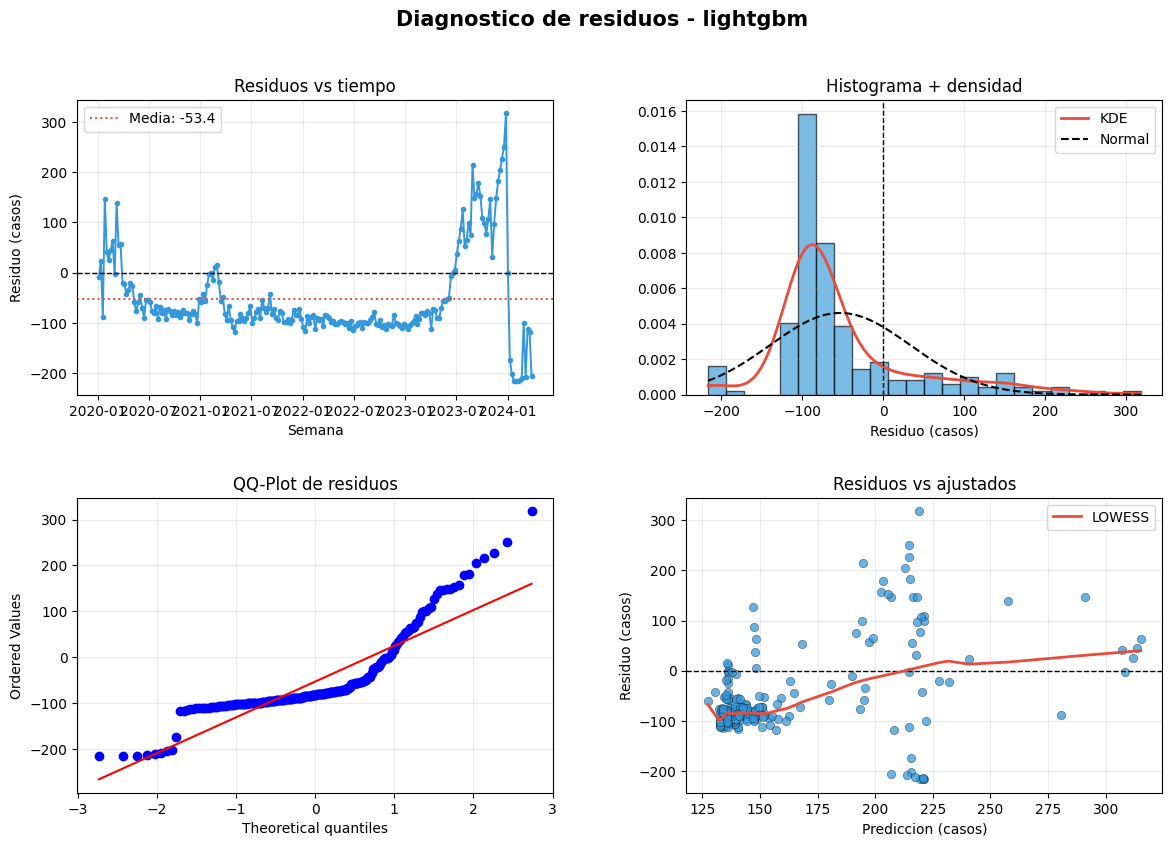

In [23]:
def graficar_diagnostico_ganador(test_df, metricas_test, ruta_salida='proyecto_2/residuos_ganador_dengue.png'):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from statsmodels.nonparametric.smoothers_lowess import lowess

    ganador = metricas_test.sort_values(['rmse', 'mae']).iloc[0]['modelo']
    sub = test_df[['ds', 'y', ganador]].dropna().copy()
    y_real = sub['y'].astype(float)
    y_pred = sub[ganador].astype(float)
    residuos = y_real - y_pred

    jb = jarque_bera(residuos)
    lag_lb = min(10, max(1, len(residuos) // 5))
    lb = acorr_ljungbox(residuos, lags=[lag_lb], return_df=True)
    dw = durbin_watson(residuos)

    print(f'Modelo ganador por RMSE: {ganador}')
    print(f'Media residuos: {residuos.mean():.2f} casos')
    print(f'Desviacion estandar: {residuos.std():.2f} casos')
    print(f'Skewness: {stats.skew(residuos):.2f} | Kurtosis: {stats.kurtosis(residuos):.2f}')
    print(f'Jarque-Bera p-value: {jb.pvalue:.4f}')
    print(f'Ljung-Box p-value lag {lag_lb}: {lb["lb_pvalue"].iloc[0]:.4f}')
    print(f'Durbin-Watson: {dw:.3f}')

    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.28)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(sub['ds'], residuos, color='#3498db', linewidth=1.4, marker='o', markersize=3)
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)
    ax1.axhline(residuos.mean(), color='#e74c3c', linestyle=':', linewidth=1.4, label=f'Media: {residuos.mean():.1f}')
    ax1.set_title('Residuos vs tiempo')
    ax1.set_xlabel('Semana')
    ax1.set_ylabel('Residuo (casos)')
    ax1.legend()
    ax1.grid(alpha=0.25)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(residuos, bins=24, density=True, color='#3498db', alpha=0.65, edgecolor='black')
    if residuos.nunique() > 1:
        x_grid = np.linspace(residuos.min(), residuos.max(), 200)
        ax2.plot(x_grid, stats.gaussian_kde(residuos)(x_grid), color='#e74c3c', linewidth=2, label='KDE')
        ax2.plot(x_grid, stats.norm.pdf(x_grid, residuos.mean(), residuos.std()), color='black', linestyle='--', linewidth=1.5, label='Normal')
    ax2.axvline(0, color='black', linestyle='--', linewidth=1)
    ax2.set_title('Histograma + densidad')
    ax2.set_xlabel('Residuo (casos)')
    ax2.legend()
    ax2.grid(alpha=0.25)

    ax3 = fig.add_subplot(gs[1, 0])
    stats.probplot(residuos, dist='norm', plot=ax3)
    ax3.set_title('QQ-Plot de residuos')
    ax3.grid(alpha=0.25)

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.scatter(y_pred, residuos, color='#3498db', alpha=0.75, edgecolors='black', linewidth=0.3)
    ax4.axhline(0, color='black', linestyle='--', linewidth=1)
    if len(y_pred) > 3 and y_pred.nunique() > 1:
        suave = lowess(residuos, y_pred, frac=0.35, return_sorted=True)
        ax4.plot(suave[:, 0], suave[:, 1], color='#e74c3c', linewidth=2, label='LOWESS')
        ax4.legend()
    ax4.set_title('Residuos vs ajustados')
    ax4.set_xlabel('Prediccion (casos)')
    ax4.set_ylabel('Residuo (casos)')
    ax4.grid(alpha=0.25)

    plt.suptitle(f'Diagnostico de residuos - {ganador}', fontsize=15, fontweight='bold')
    plt.show()

    return ganador


mejor_modelo_diagnostico = graficar_diagnostico_ganador(test_resultados, metricas_test)


In [24]:
comparacion_cv_test = metricas_cv.merge(
    metricas_test[['modelo', 'mae', 'rmse', 'mape']].rename(columns={'mae': 'mae_test', 'rmse': 'rmse_test', 'mape': 'mape_test'}),
    on='modelo',
    how='inner',
)
comparacion_cv_test = comparacion_cv_test.rename(columns={'mae': 'mae_cv', 'rmse': 'rmse_cv', 'mape': 'mape_cv'})
comparacion_cv_test['ratio_rmse_test_cv'] = comparacion_cv_test['rmse_test'] / comparacion_cv_test['rmse_cv']

print('Estabilidad CV vs Test:')
display(estilo_ranking_metricas(comparacion_cv_test.sort_values('ratio_rmse_test_cv', ascending=False)))

ranking_final = metricas_test.sort_values(['rmse', 'mae']).reset_index(drop=True)
mejor_modelo = ranking_final.loc[0, 'modelo']
mejor_mae = metricas_test.sort_values('mae').iloc[0]['modelo']
mejor_mape = metricas_test.sort_values('mape').iloc[0]['modelo']

diagnostico_mejor = diagnostico_residuos.loc[diagnostico_residuos.modelo == mejor_modelo].iloc[0]

print(f'Mejor modelo por RMSE: {mejor_modelo}')
print(f'Mejor modelo por MAE:  {mejor_mae}')
print(f'Mejor modelo por MAPE: {mejor_mape}')
print(
    'Residuales del ganador: '
    f'normalidad={diagnostico_mejor.normalidad}, '
    f'autocorrelacion={diagnostico_mejor.sin_autocorr}, '
    f'homocedasticidad={diagnostico_mejor.homocedasticidad}.'
)
print('Criterio operativo: priorizar RMSE para penalizar errores grandes durante brotes, revisando MAE/MAPE, estabilidad CV/test y diagnostico de residuos antes de recomendar produccion.')
display(estilo_ranking_metricas(ranking_final.head(8)))


Estabilidad CV vs Test:


,modelo,mae_cv,rmse_cv,mape_cv,familia,mae_test,rmse_test,mape_test,ratio_rmse_test_cv
1,AutoETS_208,19.67,25.66,327.52,suavizacion,162.26,179.45,653.50,6.99
0,WindowAverage,18.30,24.19,142.50,baseline,99.93,115.62,299.54,4.78
4,RWD,23.44,29.61,212.58,baseline,130.19,140.11,464.71,4.73
2,Theta_208,22.42,28.50,198.76,suavizacion,111.83,123.03,350.36,4.32
3,Naive,22.47,28.56,199.39,baseline,111.99,123.14,351.03,4.31
5,AutoARIMA_208,35.91,42.50,403.74,arima_sarima,118.39,127.95,377.18,3.01
6,random_forest,38.30,45.17,510.18,ml_ensemble_boosting,113.56,123.75,380.63,2.74
7,lightgbm,39.50,45.84,500.67,ml_ensemble_boosting,90.36,101.56,369.69,2.22
9,ridge,70.65,79.22,851.33,ml_lineal,91.10,135.98,84.36,1.72
10,lasso,71.91,81.11,880.56,ml_lineal,88.78,134.06,82.80,1.65


Mejor modelo por RMSE: lightgbm
Mejor modelo por MAE:  SARIMA_manual
Mejor modelo por MAPE: lasso
Residuales del ganador: normalidad=Revisar, autocorrelacion=Revisar, homocedasticidad=Revisar.
Criterio operativo: priorizar RMSE para penalizar errores grandes durante brotes, revisando MAE/MAPE, estabilidad CV/test y diagnostico de residuos antes de recomendar produccion.


,modelo,conjunto,mae,mape,rmse,familia,tiempo_segundos,mejora_mae_vs_SeasonalNaive,mejora_rmse_vs_SeasonalNaive,mejora_mape_vs_SeasonalNaive,mejora_mae_vs_WindowAverage,mejora_rmse_vs_WindowAverage,mejora_mape_vs_WindowAverage
0,lightgbm,test,90.36,369.69,101.56,ml_ensemble_boosting,7.62,-10.43,16.63,-0.09,9.57,12.16,-23.42
1,SARIMA_manual,test,61.94,117.06,109.01,arima_sarima,17.80,24.31,10.52,68.31,38.02,5.72,60.92
2,WindowAverage,test,99.93,299.54,115.62,baseline,nan,-22.12,5.09,18.90,0.00,0.00,0.00
3,SeasonalNaive,test,81.83,369.36,121.82,baseline,nan,0.00,0.00,0.00,18.11,-5.37,-23.31
4,Theta_208,test,111.83,350.36,123.03,suavizacion,3.26,-36.66,-0.99,5.14,-11.91,-6.41,-16.97
5,Naive,test,111.99,351.03,123.14,baseline,nan,-36.86,-1.08,4.96,-12.07,-6.51,-17.19
6,random_forest,test,113.56,380.63,123.75,ml_ensemble_boosting,7.62,-38.78,-1.58,-3.05,-13.65,-7.04,-27.07
7,AutoARIMA_208,test,118.39,377.18,127.95,arima_sarima,17.80,-44.68,-5.03,-2.12,-18.48,-10.67,-25.92


---
## RESUMEN FINAL

Este notebook implementa los ocho modelos obligatorios de fase 2 y los compara contra los baselines de referencia con el mismo split temporal.

La recomendacion final se calcula programaticamente en la seccion anterior, priorizando RMSE por su importancia durante brotes, pero contrastando con MAE, MAPE, estabilidad CV/test, mejora frente a baselines y diagnostico de residuos.

Limitacion metodologica principal: los modelos usan historia de casos y calendario. Sin covariables climaticas, entomologicas o de intervencion, pueden capturar persistencia y patrones temporales, pero no necesariamente anticipar con suficiente anticipacion cambios abruptos de regimen epidemiologico.
